MERGE DATASET


In [ ]:
import pandas as pd
import os

print("="*50)
print("MERGING TRAINING DATA...")
print("="*50)

# Daftar file training
train_files = [
    '/content/fox_wazuh.csv',
    '/content/russellmitchell_wazuh.csv',
    '/content/santos_wazuh.csv',
    '/content/shaw_wazuh.csv'
]

dfs = []
for f in train_files:
    if os.path.exists(f):
        df_temp = pd.read_csv(f)
        dfs.append(df_temp)
        print(f"✓ Loaded {f.split('/')[-1]} ({len(df_temp)} rows)")
    else:
        print(f"✗ {f.split('/')[-1]} tidak ditemukan!")

# Gabungkan dan simpan
if dfs:
    df_merged = pd.concat(dfs, ignore_index=True)
    output_path = '/content/merged_train_wazuh.csv'
    df_merged.to_csv(output_path, index=False)
    print(f"\n✓ Berhasil menggabungkan {len(dfs)} file!")
    print(f"✓ Total baris: {len(df_merged)}")
    print(f"✓ File tersimpan di: {output_path}")
else:
    print("Tidak ada file yang berhasil dimuat.")

MERGING TRAINING DATA...
✓ Loaded fox_wazuh.csv (462523 rows)
✓ Loaded russellmitchell_wazuh.csv (41488 rows)
✓ Loaded santos_wazuh.csv (126513 rows)
✓ Loaded shaw_wazuh.csv (30640 rows)

✓ Berhasil menggabungkan 4 file!
✓ Total baris: 661164
✓ File tersimpan di: /content/merged_train_wazuh.csv


train RF

In [ ]:
import pandas as pd
import numpy as np
import joblib
import gc
import warnings
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

!pip install category_encoders -q
import category_encoders as ce

warnings.filterwarnings('ignore')

print("="*60)
print("1. PREPROCESSING DATA TRAINING (HEMAT RAM + PREVIEW)")
print("="*60)

# ==========================================
# 1. LOAD DATA + DOWNGRADE DTYPE (HEMAT RAM)
# ==========================================
df_train = pd.read_csv('/content/merged_train_wazuh.csv')
print(f"✓ Loaded: {len(df_train)} rows")

# Downcast numeric untuk hemat RAM
for col in df_train.select_dtypes(include=['int64']).columns:
    df_train[col] = pd.to_numeric(df_train[col], downcast='integer')
for col in df_train.select_dtypes(include=['float64']).columns:
    df_train[col] = pd.to_numeric(df_train[col], downcast='float')

# ==========================================
# 2. HAPUS LEAKAGE (inplace)
# ==========================================
leakage_features = ['rule_level', 'decoder_name', 'groups']
df_train.drop(columns=[c for c in leakage_features if c in df_train.columns], inplace=True)

# ==========================================
# 3. PENANGANAN NaN
# ==========================================
df_train['is_incomplete'] = df_train.isnull().any(axis=1).astype(np.int8)

for col in ['program_name', 'description', 'location', 'input_type']:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna('MISSING_DATA')

for col in ['hour', 'day_of_week', 'rule_id', 'firedtimes']:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna(df_train[col].median())

# ==========================================
# 4. PISAH X & y
# ==========================================
features_to_drop = ['ts_epoch', 'agent_id', 'label']
y_train = df_train['label'].copy()
X_train_raw = df_train.drop(columns=[c for c in features_to_drop if c in df_train.columns], inplace=False)
del df_train  # 🗑️ BEBASKAN RAM
gc.collect()

encoders = {}

# ==========================================
# 5. ONE-HOT ENCODING (Low Cardinality)
# ==========================================
low_card_cols = ['day_of_week', 'input_type', 'is_incomplete']
low_card_cols = [c for c in low_card_cols if c in X_train_raw.columns]
if low_card_cols:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)
    ohe.fit(X_train_raw[low_card_cols])
    X_train_ohe = pd.DataFrame(
        ohe.transform(X_train_raw[low_card_cols]),
        columns=ohe.get_feature_names_out(low_card_cols),
        index=X_train_raw.index,
        dtype=np.float32
    )
    X_train_raw.drop(columns=low_card_cols, inplace=True)
    encoders['ohe'] = ohe
    gc.collect()
    print(f"✓ One-Hot Encoding: {len(low_card_cols)} kolom")

# ==========================================
# 6. ORDINAL ENCODING (Medium Cardinality)
# ==========================================
ordinal_cols = ['program_name', 'hour', 'rule_id']
ordinal_cols = [c for c in ordinal_cols if c in X_train_raw.columns]
if ordinal_cols:
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32)
    oe.fit(X_train_raw[ordinal_cols])
    X_train_raw[ordinal_cols] = oe.transform(X_train_raw[ordinal_cols]).astype(np.float32)
    encoders['ordinal'] = oe
    gc.collect()
    print(f"✓ Ordinal Encoding: {len(ordinal_cols)} kolom")

# ==========================================
# 7. TF-IDF UNTUK TEKS
# ==========================================
text_cols = ['description', 'location']
text_cols = [c for c in text_cols if c in X_train_raw.columns]

if text_cols:
    text_to_vectorize = X_train_raw[text_cols].fillna('').astype(str).agg(' '.join, axis=1)
    X_train_raw.drop(columns=text_cols, inplace=True)
    gc.collect()

    tfidf = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        dtype=np.float32
    )
    X_tfidf = tfidf.fit_transform(text_to_vectorize)

    tfidf_cols = [f'tfidf_{i}' for i in range(X_tfidf.shape[1])]
    X_tfidf_df = pd.DataFrame(
        X_tfidf.toarray(),
        columns=tfidf_cols,
        index=X_train_raw.index,
        dtype=np.float32
    )

    X_train_raw = pd.concat([X_train_raw, X_tfidf_df], axis=1)
    encoders['tfidf'] = tfidf

    del text_to_vectorize, X_tfidf, X_tfidf_df
    gc.collect()
    print(f"✓ TF-IDF: 1000 fitur teks")

# ==========================================
# 8. GABUNGKAN SEMUA FITUR
# ==========================================
if 'ohe' in encoders:
    X_train = pd.concat([X_train_raw, X_train_ohe], axis=1)
    del X_train_ohe
else:
    X_train = X_train_raw

del X_train_raw
gc.collect()

X_train = X_train.astype(np.float32)

# ==========================================
# 9. HAPUS NaN DI y_train
# ==========================================
nan_in_y_train_idx = y_train[y_train.isna()].index
if not nan_in_y_train_idx.empty:
    print(f"⚠️ Menghapus {len(nan_in_y_train_idx)} baris dengan NaN di 'label'.")
    X_train = X_train.drop(nan_in_y_train_idx)
    y_train = y_train.drop(nan_in_y_train_idx)

print(f"\n✅ Preprocessing Selesai!")
print(f"✅ Shape X_train: {X_train.shape}")
print(f"✅ Shape y_train: {y_train.shape}")

# ==========================================
# 📊 PREVIEW BEBERAPA BARIS SAJA
# ==========================================
print("\n" + "="*60)
print("📊 PREVIEW DATA (5 BARIS PERTAMA)")
print("="*60)

print("\n🔹 X_train (5 kolom pertama × 5 baris):")
display(X_train.iloc[:5, :5])

print("\n🔹 y_train (5 baris pertama):")
display(y_train.head())

print("\n🔹 Info kolom:")
print(f"   Total fitur: {X_train.shape[1]}")
print(f"   Contoh nama kolom: {list(X_train.columns[:10])}")

print("\n💡 Tip: Data sudah siap untuk training!")

1. PREPROCESSING DATA TRAINING (HEMAT RAM + PREVIEW)
✓ Loaded: 661164 rows
✓ One-Hot Encoding: 3 kolom
✓ Ordinal Encoding: 3 kolom
✓ TF-IDF: 1000 fitur teks

✅ Preprocessing Selesai!
✅ Shape X_train: (661164, 435)
✅ Shape y_train: (661164,)

📊 PREVIEW DATA (5 BARIS PERTAMA)

🔹 X_train (5 kolom pertama × 5 baris):


,hour,rule_id,firedtimes,program_name,tfidf_0
0,2.0,27.0,1.0,4.0,0.0
1,2.0,27.0,2.0,4.0,0.0
2,2.0,27.0,3.0,4.0,0.0
3,2.0,27.0,4.0,4.0,0.0
4,2.0,27.0,5.0,4.0,0.0



🔹 y_train (5 baris pertama):


,label
0,0
1,0
2,0
3,0
4,0



🔹 Info kolom:
   Total fitur: 435
   Contoh nama kolom: ['hour', 'rule_id', 'firedtimes', 'program_name', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5']

💡 Tip: Data sudah siap untuk training!


2. TRAINING & EVALUASI (HEMAT RAM + PREVIEW)

⚠️  X_train / y_train TIDAK DITEMUKAN!
   Kemungkinan: Cell preprocessing belum dijalankan atau runtime di-restart.
   📂 Menemukan file backup. Loading...
   ✓ Loaded dari backup: (661164, 435)

🔧 Optimasi RAM: konversi X_train ke float32...
✓ Data Training: 528931 | Data Validasi: 132233

🔄 Memulai training...
✅ Training Selesai!

🔮 Melakukan prediksi probabilitas...

🎯 ANALISIS TRADE-OFF THRESHOLD (Mindset: Cry than Sorry)
Threshold 0.50 | Recall: 0.9836 | Precision: 1.0000
Threshold 0.30 | Recall: 0.9840 | Precision: 1.0000
Threshold 0.10 | Recall: 0.9947 | Precision: 0.9931
Threshold 0.05 | Recall: 0.9995 | Precision: 0.9754

--- HASIL AKHIR DENGAN THRESHOLD 0.05 ---
True Positive (TP)  : 86595 (Serangan terdeteksi benar)
True Negative (TN)  : 43411 (Normal terdeteksi benar)
False Positive (FP) : 2187 (Normal dikira serangan - CRY)
False Negative (FN) : 40 (Serangan terlewat - SORRY!)
----------------------------------------
Accuracy   

,Actual,Predicted,Probability,Status
0,1,1,1.0000,✅
1,0,0,0.0039,✅
2,0,0,0.0105,✅
3,1,1,1.0000,✅
4,1,1,1.0000,✅



📈 Confusion Matrix:


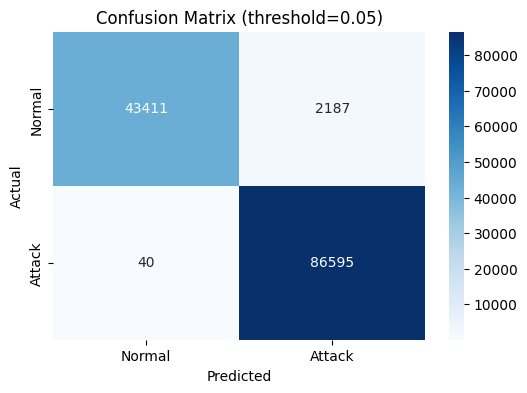


✅ Cell 2 Selesai! Lanjut ke Cell 3 untuk simpan & download.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

print("="*60)
print("2. TRAINING & EVALUASI (HEMAT RAM + PREVIEW)")
print("="*60)

# ==========================================
# 🔍 CEK APAKAH X_train SUDAH ADA
# ==========================================
if 'X_train' not in dir() or 'y_train' not in dir():
    print("\n⚠️  X_train / y_train TIDAK DITEMUKAN!")
    print("   Kemungkinan: Cell preprocessing belum dijalankan atau runtime di-restart.")

    # Coba load dari file backup (jika ada)
    if os.path.exists('/content/X_train_final.csv') and os.path.exists('/content/y_train_final.csv'):
        print("   📂 Menemukan file backup. Loading...")
        X_train = pd.read_csv('/content/X_train_final.csv')
        y_train = pd.read_csv('/content/y_train_final.csv')['label']
        print(f"   ✓ Loaded dari backup: {X_train.shape}")
    else:
        raise RuntimeError(
            "\n❌ X_train tidak ada & tidak ada file backup.\n"
            "   ➡️  SOLUSI: Jalankan CELL PREPROCESSING terlebih dahulu!"
        )
else:
    print(f"✓ X_train ditemukan: {X_train.shape}")
    print(f"✓ y_train ditemukan: {y_train.shape}")

# ==========================================
# 🚀 OPTIMASI 1: Downcast X_train ke float32
# ==========================================
print("\n🔧 Optimasi RAM: konversi X_train ke float32...")
X_train = X_train.astype(np.float32)
gc.collect()

# ==========================================
# 1. BAGI DATA UNTUK VALIDASI
# ==========================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"✓ Data Training: {len(X_tr)} | Data Validasi: {len(X_val)}")

# Bebaskan X_train asli (sudah di-split)
del X_train, y_train
gc.collect()

# --- PARAMETER MODEL (DIOPTIMASI UNTUK RAM) ---
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    warm_start=False
)

print("\n🔄 Memulai training...")
rf_model.fit(X_tr, y_tr)
print("✅ Training Selesai!")

# 🗑️ Bebaskan X_tr (tidak dipakai lagi setelah training)
del X_tr
gc.collect()

# ==========================================
# 2. EVALUASI DENGAN THRESHOLD TUNING
# ==========================================
print("\n🔮 Melakukan prediksi probabilitas...")
y_proba = rf_model.predict_proba(X_val)[:, 1].astype(np.float32)

thresholds_to_test = [0.5, 0.3, 0.1, 0.05]

print("\n" + "="*60)
print("🎯 ANALISIS TRADE-OFF THRESHOLD (Mindset: Cry than Sorry)")
print("="*60)

for thresh in thresholds_to_test:
    y_pred_temp = (y_proba >= thresh).astype(np.int8)
    rec = recall_score(y_val, y_pred_temp, zero_division=0)
    prec = precision_score(y_val, y_pred_temp, zero_division=0)
    print(f"Threshold {thresh:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f}")
    del y_pred_temp
    gc.collect()

threshold_pilihan = 0.05
y_pred_final = (y_proba >= threshold_pilihan).astype(np.int8)

# Hitung Metrik Akhir
cm = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print(f"\n--- HASIL AKHIR DENGAN THRESHOLD {threshold_pilihan} ---")
print(f"True Positive (TP)  : {tp} (Serangan terdeteksi benar)")
print(f"True Negative (TN)  : {tn} (Normal terdeteksi benar)")
print(f"False Positive (FP) : {fp} (Normal dikira serangan - CRY)")
print(f"False Negative (FN) : {fn} (Serangan terlewat - SORRY!)")
print("-" * 40)
print(f"Accuracy            : {accuracy_score(y_val, y_pred_final)*100:.2f}%")
print(f"Recall              : {recall_score(y_val, y_pred_final, zero_division=0)*100:.2f}%")
print(f"Precision           : {precision_score(y_val, y_pred_final, zero_division=0)*100:.2f}%")

# ==========================================
# 3. ANALISIS FALSE NEGATIVE
# ==========================================
print("\n" + "="*60)
if fn == 0:
    print("🎉 SUKSES TOTAL! False Negative = 0. Zero Sorry!")
else:
    print(f"⚠️ Masih ada {fn} Serangan yang terlewat. Menganalisis penyebab...")

    fn_mask = (y_val.values == 1) & (y_pred_final == 0)
    fn_indices = np.where(fn_mask)[0]

    incomplete_col = [col for col in X_val.columns if 'is_incomplete' in col and '1' in col]

    if incomplete_col:
        col_name = incomplete_col[0]
        fn_incomplete_count = X_val.iloc[fn_indices][col_name].sum()
        print(f"   -> Dari {fn} FN, {int(fn_incomplete_count)} adalah log TIDAK LENGKAP (NaN).")
        print(f"   -> {int(fn - fn_incomplete_count)} adalah log LENGKAP tapi tetap terlewat.")
    else:
        print("   -> Fitur 'is_incomplete' tidak ditemukan di data validasi.")

    fn_proba = y_proba[fn_indices]
    print(f"\n   Rata-rata probabilitas untuk {fn} data FN:")
    print(f"   Mean: {np.mean(fn_proba):.4f} | Max: {np.max(fn_proba):.4f}")
    del fn_proba
    print("   💡 Saran: Jika mean <0.05 → model tidak yakin. Jika >0.3 → turunkan threshold.")

# ==========================================
# 4. FEATURE IMPORTANCE
# ==========================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n🔍 Top 10 Fitur Paling Penting:")
for i in range(min(10, len(importances))):
    feat_name = X_val.columns[indices[i]]
    if 'tfidf' in feat_name:
        feat_name = feat_name[:15] + "..."
    print(f"  {i+1}. {feat_name}: {importances[indices[i]]:.4f}")

# ==========================================
# 📊 5. PREVIEW HASIL
# ==========================================
print("\n" + "="*60)
print("📊 PREVIEW HASIL PREDIKSI (5 BARIS PERTAMA)")
print("="*60)

preview_df = pd.DataFrame({
    'Actual': y_val.values[:5],
    'Predicted': y_pred_final[:5],
    'Probability': np.round(y_proba[:5], 4),
    'Status': ['✅' if y_val.values[i] == y_pred_final[i] else '❌' for i in range(5)]
})
display(preview_df)

print("\n📈 Confusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix (threshold={threshold_pilihan})')
plt.show()

print("\n✅ Cell 2 Selesai! Lanjut ke Cell 3 untuk simpan & download.")

In [ ]:
print(X_train.shape)

(661164, 435)


In [ ]:
import joblib
import pandas as pd
import json
from sklearn.metrics import accuracy_score, recall_score, precision_score
from google.colab import files

print("="*60)
print("💾 SIMPAN & DOWNLOAD: MODEL, ENCODER, CONFIG")
print("="*60)

# ==========================================
# 1. SIMPAN MODEL
# ==========================================
joblib.dump(rf_model, '/content/rf_model_fix.pkl')
print("✅ rf_model.pkl")

# ==========================================
# 2. SIMPAN ENCODER
# ==========================================
joblib.dump(encoders, '/content/encoders_fix.pkl')
print("✅ encoders.pkl")

# ==========================================
# 3. SIMPAN CONFIG
# ==========================================
config = {
    'threshold': float(threshold_pilihan),
    'feature_names': list(X_val.columns),
    'model_params': {
        'n_estimators': rf_model.n_estimators,
        'max_depth': rf_model.max_depth,
        'min_samples_split': rf_model.min_samples_split,
        'min_samples_leaf': rf_model.min_samples_leaf,
        'max_features': str(rf_model.max_features),
        'class_weight': 'balanced'
    },
    'metrics': {
        'accuracy': float(accuracy_score(y_val, y_pred_final)),
        'recall': float(recall_score(y_val, y_pred_final, zero_division=0)),
        'precision': float(precision_score(y_val, y_pred_final, zero_division=0)),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    },
    'timestamp': pd.Timestamp.now().isoformat()
}

with open('/content/config._fix.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ config.json")

# ==========================================
# 4. DOWNLOAD
# ==========================================
print("\n⬇️ Downloading...")
files.download('/content/rf_model_fix.pkl')
files.download('/content/encoders_fix.pkl')
files.download('/content/config._fix.json')

print("\n🎉 Done! 3 file berhasil didownload.")

💾 SIMPAN & DOWNLOAD: MODEL, ENCODER, CONFIG
✅ rf_model.pkl
✅ encoders.pkl
✅ config.json

⬇️ Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Done! 3 file berhasil didownload.


LAST TEST


INFERENCE DATA HARRISON (PAKAI MODEL .pkl)

Loading artefak model...
   [OK] rf_model_fix.pkl
   [OK] encoders_fix.pkl
   [OK] config._fix.json

Info Model:
   Threshold   : 0.05
   Jumlah fitur: 435
   Metrik train: Recall=0.9995, Precision=0.9754

LOAD DATA HARRISON
[OK] Loaded: 583754 rows, 14 kolom
[OK] Kolom: ['hour', 'day_of_week', 'rule_level', 'rule_id', 'firedtimes', 'decoder_name', 'program_name', 'description', 'groups', 'location', 'input_type', 'agent_id', 'ts_epoch', 'label']

DISTRIBUSI LABEL ASLI (DATA HARRISON)

   Label 0 (Normal)  : 157,533 (26.99%)
   Label 1 (Serangan): 426,221 (73.01%)
   Total data        : 583,754


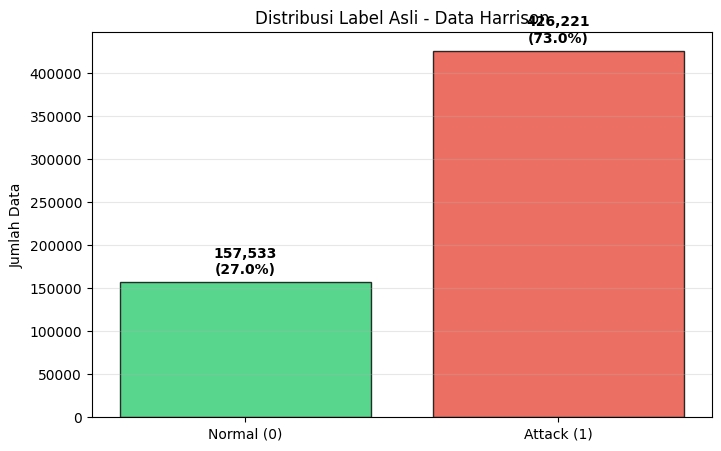


PREPROCESSING DATA HARRISON

Cek kesesuaian kolom:
   [str] Ada: 4 | Tidak ada: 0
   [num] Ada: 4 | Tidak ada: 0
   [leakage] Ada: 3 | Tidak ada: 0
   [drop] Ada: 3 | Tidak ada: 0

Applying encoders...
   [OK] OHE: 10 kolom
   [OK] Ordinal: 3 kolom
   [OK] TF-IDF: 421 fitur

Menyesuaikan kolom dengan training...

[OK] Preprocessing Harrison selesai!
   Shape final: (583754, 435)

INFERENCE: PREDIKSI DATA HARRISON

HASIL PREDIKSI (threshold = 0.05):
   Total data           : 583,754
   Terdeteksi SERANGAN  : 424,263 (72.68%)
   Normal               : 159,491 (27.32%)

EVALUASI METRIK vs LABEL ASLI

CONFUSION MATRIX:
   True Positive  (TP): 416,514   -> Serangan terdeteksi benar
   True Negative  (TN): 149,784   -> Normal terdeteksi benar
   False Positive (FP): 7,749   -> Normal dikira serangan (CRY)
   False Negative (FN): 9,707   -> Serangan terlewat (SORRY)

METRIK EVALUASI:
   Accuracy  : 97.01%
   Precision : 98.17%
   Recall    : 97.72%
   F1-Score  : 97.95%


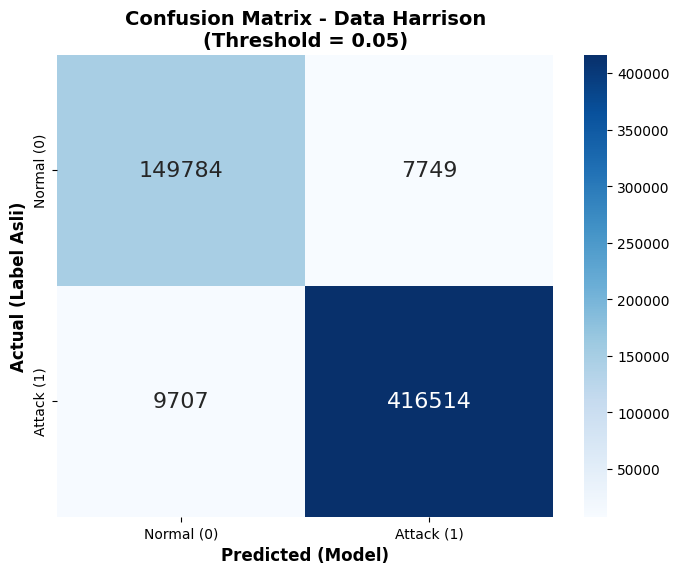


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Normal (0)       0.94      0.95      0.94    157533
  Attack (1)       0.98      0.98      0.98    426221

    accuracy                           0.97    583754
   macro avg       0.96      0.96      0.96    583754
weighted avg       0.97      0.97      0.97    583754


ANALISIS KESALAHAN

[WARN] FALSE POSITIVE (7749 data):
   -> Data normal yang dikira serangan
   -> Rata-rata probabilitas: 0.1058
   -> Max probabilitas: 0.6350

[WARN] FALSE NEGATIVE (9707 data):
   -> Serangan yang terlewat
   -> Rata-rata probabilitas: 0.0159
   -> Max probabilitas: 0.0497
   -> Saran: Jika mean proba FN tinggi (>0.3), coba turunkan threshold

ANALISIS DETAIL

Statistik Probabilitas:
   Mean   : 0.7160
   Median : 1.0000
   Min    : 0.0000
   Max    : 1.0000


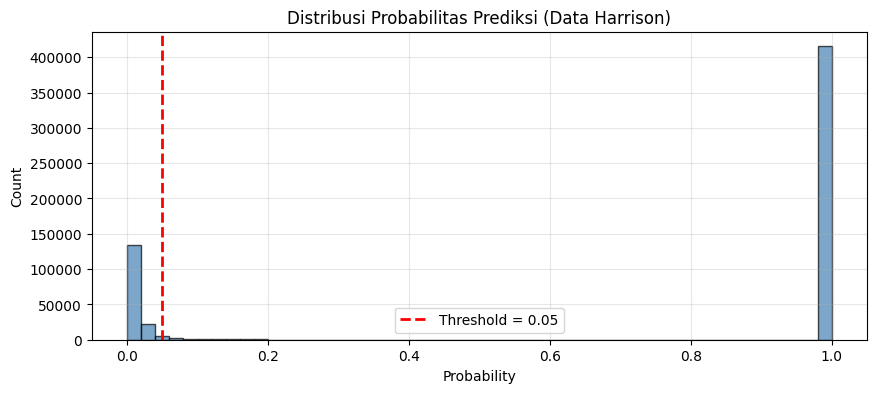


MENYIMPAN HASIL INFERENCE
[OK] Tersimpan: /content/harrison_predictions.csv
[OK] Tersimpan: /content/harrison_summary.json



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


INFERENCE HARRISON SELESAI!


In [ ]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("="*70)
print("INFERENCE DATA HARRISON (PAKAI MODEL .pkl)")
print("="*70)

# ==========================================
# 1. LOAD MODEL, ENCODER, CONFIG
# ==========================================
print("\nLoading artefak model...")

rf_model = joblib.load('/content/rf_model_fix.pkl')
print("   [OK] rf_model_fix.pkl")

encoders = joblib.load('/content/encoders_fix.pkl')
print("   [OK] encoders_fix.pkl")

with open('/content/config._fix.json', 'r') as f:
    config = json.load(f)
print("   [OK] config._fix.json")

threshold_pilihan = config['threshold']
feature_names = config['feature_names']

print(f"\nInfo Model:")
print(f"   Threshold   : {threshold_pilihan}")
print(f"   Jumlah fitur: {len(feature_names)}")
print(f"   Metrik train: Recall={config['metrics']['recall']:.4f}, Precision={config['metrics']['precision']:.4f}")

# ==========================================
# 2. LOAD DATA HARRISON
# ==========================================
print("\n" + "="*70)
print("LOAD DATA HARRISON")
print("="*70)

harrison_path = '/content/harrison_wazuh.csv'

try:
    df_harris = pd.read_csv(harrison_path)
    print(f"[OK] Loaded: {len(df_harris)} rows, {len(df_harris.columns)} kolom")
    print(f"[OK] Kolom: {list(df_harris.columns)}")
except FileNotFoundError:
    raise FileNotFoundError(
        f"[ERROR] File {harrison_path} tidak ditemukan!\n"
        f"   -> Upload file Harrison.csv dulu, atau sesuaikan path di atas."
    )

# ==========================================
# 2b. ANALISIS DISTRIBUSI LABEL ASLI
# ==========================================
print("\n" + "="*70)
print("DISTRIBUSI LABEL ASLI (DATA HARRISON)")
print("="*70)

y_true_harris = None
if 'label' in df_harris.columns:
    y_true_harris = df_harris['label'].values

    total_0 = (y_true_harris == 0).sum()
    total_1 = (y_true_harris == 1).sum()
    total_all = len(y_true_harris)

    print(f"\n   Label 0 (Normal)  : {total_0:,} ({total_0/total_all*100:.2f}%)")
    print(f"   Label 1 (Serangan): {total_1:,} ({total_1/total_all*100:.2f}%)")
    print(f"   Total data        : {total_all:,}")

    # Visualisasi distribusi label
    plt.figure(figsize=(8, 5))
    labels_dist = ['Normal (0)', 'Attack (1)']
    counts = [total_0, total_1]
    colors = ['#2ecc71', '#e74c3c']

    plt.bar(labels_dist, counts, color=colors, edgecolor='black', alpha=0.8)
    plt.ylabel('Jumlah Data')
    plt.title('Distribusi Label Asli - Data Harrison')
    plt.grid(axis='y', alpha=0.3)

    for i, v in enumerate(counts):
        plt.text(i, v + total_all*0.01, f'{v:,}\n({v/total_all*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

    plt.show()
else:
    print("[WARN] Kolom 'label' tidak ditemukan di data Harrison.")
    print("   Tidak bisa melakukan evaluasi metrik.")

# ==========================================
# 3. PREPROCESSING DATA HARRISON
# ==========================================
print("\n" + "="*70)
print("PREPROCESSING DATA HARRISON")
print("="*70)

kolom_dibutuhkan = {
    'str': ['program_name', 'description', 'location', 'input_type'],
    'num': ['hour', 'day_of_week', 'rule_id', 'firedtimes'],
    'leakage': ['rule_level', 'decoder_name', 'groups'],
    'drop': ['ts_epoch', 'agent_id', 'label']
}

print("\nCek kesesuaian kolom:")
for kategori, cols in kolom_dibutuhkan.items():
    ada = [c for c in cols if c in df_harris.columns]
    tidak_ada = [c for c in cols if c not in df_harris.columns]
    print(f"   [{kategori}] Ada: {len(ada)} | Tidak ada: {len(tidak_ada)}")

df_harris['is_incomplete'] = df_harris.isnull().any(axis=1).astype(np.int8)

for col in kolom_dibutuhkan['str']:
    if col in df_harris.columns:
        df_harris[col] = df_harris[col].fillna('MISSING_DATA')

for col in kolom_dibutuhkan['num']:
    if col in df_harris.columns:
        df_harris[col] = df_harris[col].fillna(df_harris[col].median())

for feat in kolom_dibutuhkan['leakage']:
    if feat in df_harris.columns:
        df_harris = df_harris.drop(columns=[feat])

X_harris_raw = df_harris.drop(
    columns=[c for c in kolom_dibutuhkan['drop'] if c in df_harris.columns],
    errors='ignore'
)

# ==========================================
# 4. APLIKASI ENCODER
# ==========================================
print("\nApplying encoders...")

X_harris_ohe = pd.DataFrame(index=X_harris_raw.index)
if 'ohe' in encoders:
    low_card_cols = ['day_of_week', 'input_type', 'is_incomplete']
    low_card_cols = [c for c in low_card_cols if c in X_harris_raw.columns]
    if low_card_cols:
        for col in ['day_of_week', 'input_type', 'is_incomplete']:
            if col not in X_harris_raw.columns:
                X_harris_raw[col] = 0 if col == 'is_incomplete' else 'MISSING_DATA'

        X_harris_ohe = pd.DataFrame(
            encoders['ohe'].transform(X_harris_raw[low_card_cols]),
            columns=encoders['ohe'].get_feature_names_out(low_card_cols),
            index=X_harris_raw.index,
            dtype=np.float32
        )
        X_harris_raw = X_harris_raw.drop(columns=low_card_cols, errors='ignore')
        print(f"   [OK] OHE: {X_harris_ohe.shape[1]} kolom")

if 'ordinal' in encoders:
    ordinal_cols = ['program_name', 'hour', 'rule_id']
    ordinal_cols = [c for c in ordinal_cols if c in X_harris_raw.columns]
    if ordinal_cols:
        for col in ['program_name', 'hour', 'rule_id']:
            if col not in X_harris_raw.columns:
                X_harris_raw[col] = 'MISSING_DATA' if col == 'program_name' else 0

        X_harris_raw[ordinal_cols] = encoders['ordinal'].transform(
            X_harris_raw[ordinal_cols]
        ).astype(np.float32)
        print(f"   [OK] Ordinal: {len(ordinal_cols)} kolom")

if 'tfidf' in encoders:
    text_cols = ['description', 'location']
    text_cols = [c for c in text_cols if c in X_harris_raw.columns]

    if text_cols:
        for col in ['description', 'location']:
            if col not in X_harris_raw.columns:
                X_harris_raw[col] = 'MISSING_DATA'

        text_combined = X_harris_raw[text_cols].fillna('').astype(str).agg(' '.join, axis=1)
        X_harris_raw = X_harris_raw.drop(columns=text_cols, errors='ignore')

        X_tfidf = encoders['tfidf'].transform(text_combined)
        tfidf_cols = [f'tfidf_{i}' for i in range(X_tfidf.shape[1])]
        X_tfidf_df = pd.DataFrame(
            X_tfidf.toarray(),
            columns=tfidf_cols,
            index=X_harris_raw.index,
            dtype=np.float32
        )
        X_harris_raw = pd.concat([X_harris_raw, X_tfidf_df], axis=1)
        print(f"   [OK] TF-IDF: {X_tfidf_df.shape[1]} fitur")

# ==========================================
# 5. GABUNG & SESUAIKAN KOLOM
# ==========================================
print("\nMenyesuaikan kolom dengan training...")

if not X_harris_ohe.empty:
    X_harris_final = pd.concat([X_harris_raw, X_harris_ohe], axis=1)
else:
    X_harris_final = X_harris_raw

missing_cols = set(feature_names) - set(X_harris_final.columns)
if missing_cols:
    print(f"   [WARN] {len(missing_cols)} kolom training tidak ada di Harrison -> diisi 0")
    for col in missing_cols:
        X_harris_final[col] = 0

extra_cols = set(X_harris_final.columns) - set(feature_names)
if extra_cols:
    print(f"   [WARN] {len(extra_cols)} kolom ekstra di Harrison -> dihapus")
    X_harris_final = X_harris_final.drop(columns=list(extra_cols))

X_harris_final = X_harris_final[feature_names].astype(np.float32)

print(f"\n[OK] Preprocessing Harrison selesai!")
print(f"   Shape final: {X_harris_final.shape}")

# ==========================================
# 6. INFERENCE
# ==========================================
print("\n" + "="*70)
print("INFERENCE: PREDIKSI DATA HARRISON")
print("="*70)

y_proba_harris = rf_model.predict_proba(X_harris_final)[:, 1].astype(np.float32)
y_pred_harris = (y_proba_harris >= threshold_pilihan).astype(np.int8)

total_data = len(y_pred_harris)
total_attack = int(y_pred_harris.sum())
total_normal = total_data - total_attack

print(f"\nHASIL PREDIKSI (threshold = {threshold_pilihan}):")
print(f"   Total data           : {total_data:,}")
print(f"   Terdeteksi SERANGAN  : {total_attack:,} ({total_attack/total_data*100:.2f}%)")
print(f"   Normal               : {total_normal:,} ({total_normal/total_data*100:.2f}%)")

# ==========================================
# 7. EVALUASI METRIK (JIKA ADA LABEL ASLI)
# ==========================================
if y_true_harris is not None:
    print("\n" + "="*70)
    print("EVALUASI METRIK vs LABEL ASLI")
    print("="*70)

    # Confusion Matrix
    cm = confusion_matrix(y_true_harris, y_pred_harris)
    tn, fp, fn, tp = cm.ravel()

    print(f"\nCONFUSION MATRIX:")
    print(f"   True Positive  (TP): {tp:,}   -> Serangan terdeteksi benar")
    print(f"   True Negative  (TN): {tn:,}   -> Normal terdeteksi benar")
    print(f"   False Positive (FP): {fp:,}   -> Normal dikira serangan (CRY)")
    print(f"   False Negative (FN): {fn:,}   -> Serangan terlewat (SORRY)")

    # Hitung metrik
    accuracy = accuracy_score(y_true_harris, y_pred_harris)
    precision = precision_score(y_true_harris, y_pred_harris, zero_division=0)
    recall = recall_score(y_true_harris, y_pred_harris, zero_division=0)
    f1 = f1_score(y_true_harris, y_pred_harris, zero_division=0)

    print(f"\nMETRIK EVALUASI:")
    print(f"   Accuracy  : {accuracy*100:.2f}%")
    print(f"   Precision : {precision*100:.2f}%")
    print(f"   Recall    : {recall*100:.2f}%")
    print(f"   F1-Score  : {f1*100:.2f}%")

    # Visualisasi Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Attack (1)'],
                yticklabels=['Normal (0)', 'Attack (1)'],
                annot_kws={"size": 16})
    plt.ylabel('Actual (Label Asli)', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted (Model)', fontsize=12, fontweight='bold')
    plt.title(f'Confusion Matrix - Data Harrison\n(Threshold = {threshold_pilihan})',
             fontsize=14, fontweight='bold')
    plt.show()

    # Classification Report lengkap
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(y_true_harris, y_pred_harris,
                               target_names=['Normal (0)', 'Attack (1)']))

    # Analisis False Positive & False Negative
    print("\n" + "="*70)
    print("ANALISIS KESALAHAN")
    print("="*70)

    if fp > 0:
        fp_indices = np.where((y_true_harris == 0) & (y_pred_harris == 1))[0]
        fp_proba = y_proba_harris[fp_indices]
        print(f"\n[WARN] FALSE POSITIVE ({fp} data):")
        print(f"   -> Data normal yang dikira serangan")
        print(f"   -> Rata-rata probabilitas: {fp_proba.mean():.4f}")
        print(f"   -> Max probabilitas: {fp_proba.max():.4f}")

    if fn > 0:
        fn_indices = np.where((y_true_harris == 1) & (y_pred_harris == 0))[0]
        fn_proba = y_proba_harris[fn_indices]
        print(f"\n[WARN] FALSE NEGATIVE ({fn} data):")
        print(f"   -> Serangan yang terlewat")
        print(f"   -> Rata-rata probabilitas: {fn_proba.mean():.4f}")
        print(f"   -> Max probabilitas: {fn_proba.max():.4f}")
        print(f"   -> Saran: Jika mean proba FN tinggi (>0.3), coba turunkan threshold")

# ==========================================
# 8. ANALISIS HASIL
# ==========================================
print("\n" + "="*70)
print("ANALISIS DETAIL")
print("="*70)

print(f"\nStatistik Probabilitas:")
print(f"   Mean   : {y_proba_harris.mean():.4f}")
print(f"   Median : {np.median(y_proba_harris):.4f}")
print(f"   Min    : {y_proba_harris.min():.4f}")
print(f"   Max    : {y_proba_harris.max():.4f}")

plt.figure(figsize=(10, 4))
plt.hist(y_proba_harris, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(threshold_pilihan, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold_pilihan}')
plt.xlabel('Probability')
plt.ylabel('Count')
plt.title('Distribusi Probabilitas Prediksi (Data Harrison)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# 9. SIMPAN HASIL INFERENCE
# ==========================================
print("\n" + "="*70)
print("MENYIMPAN HASIL INFERENCE")
print("="*70)

df_result = df_harris.copy()
df_result['proba_attack'] = y_proba_harris
df_result['pred_label'] = y_pred_harris
df_result['status'] = df_result['pred_label'].map({0: 'Normal', 1: 'ATTACK'})

# PERBAIKAN ERROR: pakai np.where, bukan .map() di numpy array
if y_true_harris is not None:
    df_result['actual_label'] = y_true_harris
    df_result['correct'] = np.where(y_true_harris == y_pred_harris, 'BENAR', 'SALAH')

df_result.to_csv('/content/harrison_predictions.csv', index=False)
print("[OK] Tersimpan: /content/harrison_predictions.csv")

summary = {
    'total_data': total_data,
    'total_attack': total_attack,
    'total_normal': total_normal,
    'percent_attack': float(total_attack/total_data*100),
    'threshold': threshold_pilihan,
    'proba_mean': float(y_proba_harris.mean()),
    'proba_median': float(np.median(y_proba_harris)),
    'model_file': 'rf_model_fix.pkl',
    'timestamp': pd.Timestamp.now().isoformat()
}

if y_true_harris is not None:
    summary['metrics'] = {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)
    }

with open('/content/harrison_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("[OK] Tersimpan: /content/harrison_summary.json")

from google.colab import files
print("\nDownloading hasil...")
files.download('/content/harrison_predictions.csv')
files.download('/content/harrison_summary.json')

print("\nINFERENCE HARRISON SELESAI!")